In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle, Circle
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from scipy.optimize import minimize

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import warnings
warnings.filterwarnings("ignore")

from aefc_vortex.math_module import xp, xcipy, ensure_np_array
from aefc_vortex import utils
from aefc_vortex.imshows import imshow1, imshow2, imshow3, plot_data
from aefc_vortex import dm
from aefc_vortex import props
from aefc_vortex import aefc_2dm as aefc
import aefc_vortex.fresnel_2dm_96 as fresnel
import aefc_vortex.fraunhofer_2dm_96 as fraunhofer

Nwaves = 15
wavelength_c = 650e-9
bw = 0.10
waves = np.linspace(wavelength_c * (1-bw/2), wavelength_c * (1+bw/2), Nwaves )
bandpasses = waves.reshape(3,5)
print(bandpasses)

Nwaves_per_bp = bandpasses.shape[1]
control_waves = bandpasses[:, Nwaves_per_bp//2]
print(control_waves)

# dm1_flat = xp.rot90(xp.rot90( utils.load_fits('data/dm1_flat_command_96.fits') ))
# M = fraunhofer.MODEL()
# dm1_flat += 1e-9*xp.random.randn(M.Nact,M.Nact) * M.dm_mask

/home/kianmilani/Projects/adefc-vortex/aefc_vortex
[[6.17500000e-07 6.22142857e-07 6.26785714e-07 6.31428571e-07
  6.36071429e-07]
 [6.40714286e-07 6.45357143e-07 6.50000000e-07 6.54642857e-07
  6.59285714e-07]
 [6.63928571e-07 6.68571429e-07 6.73214286e-07 6.77857143e-07
  6.82500000e-07]]
[6.26785714e-07 6.50000000e-07 6.73214286e-07]


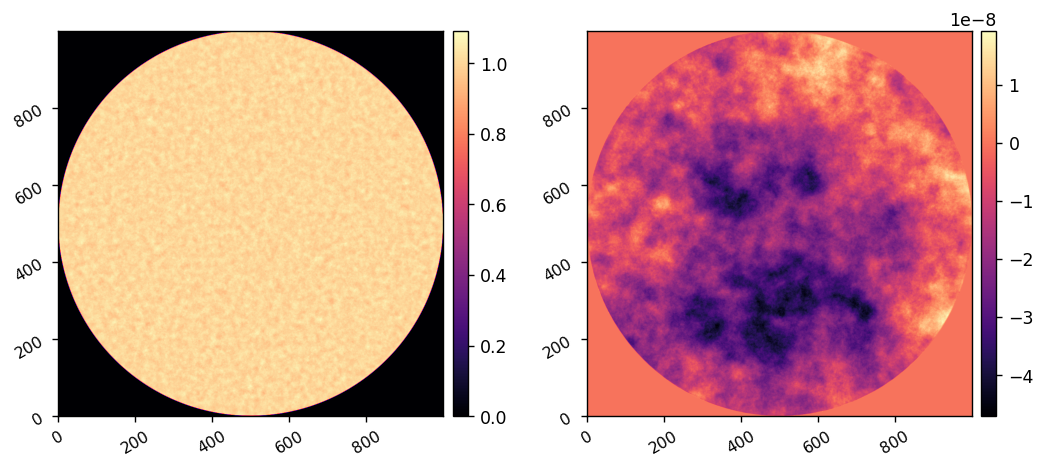

In [2]:
reload(fresnel)
I = fresnel.CORO()
I.use_opds = True

AMP, OPD = I.calc_pupil()
imshow2(AMP, OPD)

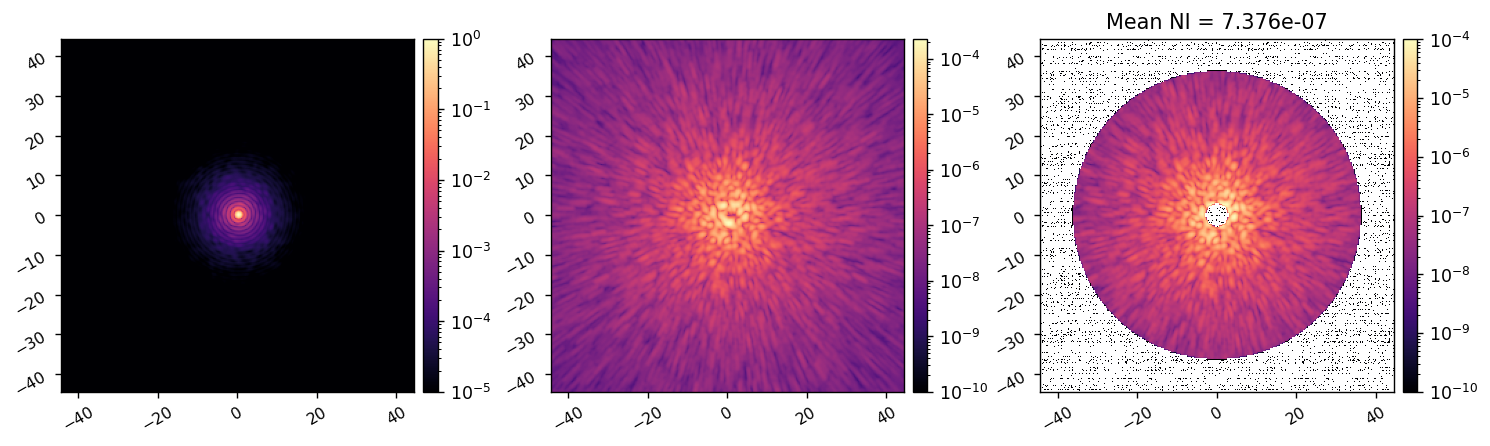

In [3]:
reload(fresnel)
I = fresnel.CORO()
I.use_opds = True
I.bandpasses = bandpasses

I.use_vortex = False
ref_psf = I.snap()
I.Imax_ref = xp.max(ref_psf)
ref_psf /= I.Imax_ref
I.use_vortex = True
ref_coro_im = I.snap()

reload(utils)
I.reset_dms()
iwa = 3
owa = 36
rot = 0
control_mask = utils.create_annular_focal_plane_mask(I.npsf, I.psf_pixelscale_lamDc, irad=iwa, orad=owa, edge=None, rotation=rot)
# control_mask = utils.create_annular_focal_plane_mask(I.npsf, I.psf_pixelscale_lamDc, irad=iwa, orad=owa, edge=iwa, rotation=rot)
mean_ni0 = xp.mean(ref_coro_im[control_mask])

imshow3(
    ref_psf, ref_coro_im, ref_coro_im*control_mask,
    '', '', f'Mean NI = {mean_ni0:.3e}',
    pxscl=I.psf_pixelscale_lamDc, 
    lognorm=True, vmin1=1e-5, vmin2=1e-10, vmin3=1e-10,
)


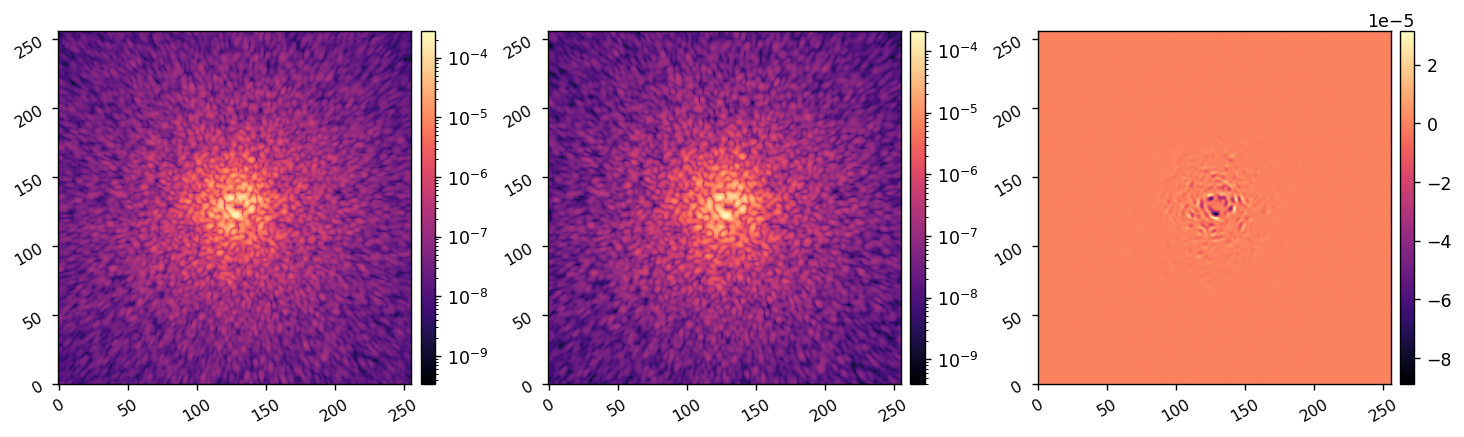

In [7]:
im_bp1 = I.snap(1)
im_bp3 = I.snap(3)
diff = im_bp3 - im_bp1
imshow3(im_bp1, im_bp3, diff, lognorm1=True, lognorm2=True, )

In [28]:
mem_usage_from_fresnel_model = 3.794

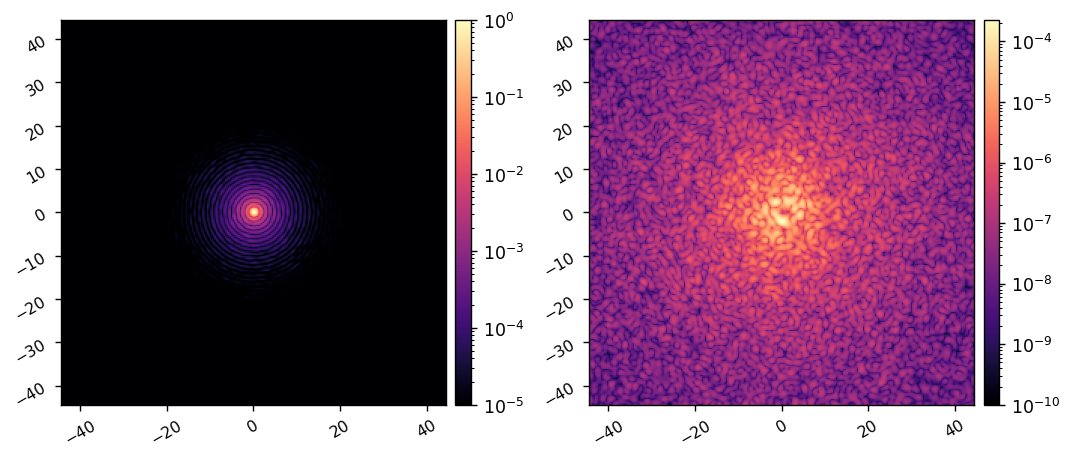

In [6]:
reload(fraunhofer)
M = fraunhofer.MODEL()
M.AMP = AMP
M.OPD = OPD

M.flip_dm = True
M.flip_lyot = True

acts = xp.zeros(M.Nacts)

model_psf = xp.abs( M.forward(acts, M.wavelength_c, use_vortex=0) )**2
M.setattr('Imax_ref', xp.max(model_psf))
model_psf /= M.Imax_ref

model_coro_im = xp.abs( M.forward(acts, M.wavelength_c, use_vortex=1) )**2

imshow2(model_psf, model_coro_im,
        pxscl=M.psf_pixelscale_lamDc, lognorm=True, vmin1=1e-5, vmin2=1e-10)

In [27]:
mem_usage_with_forward_model = 6.482

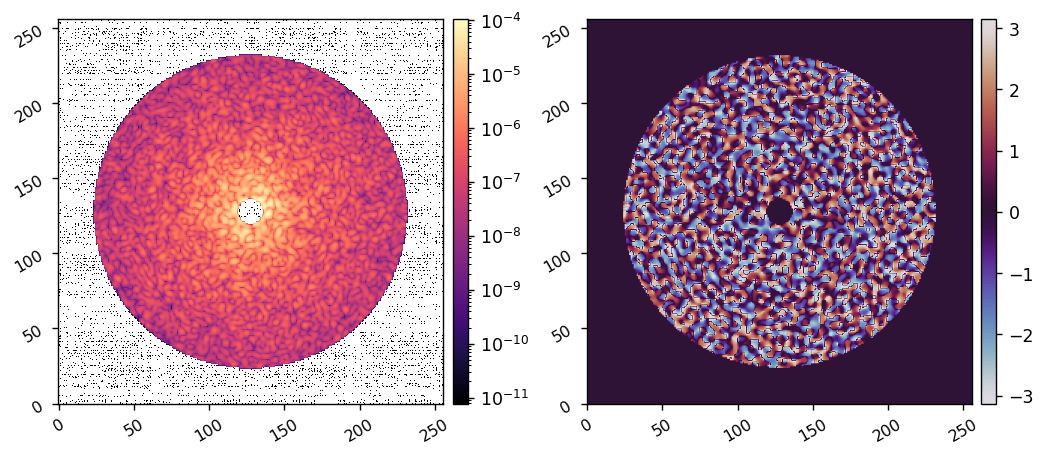

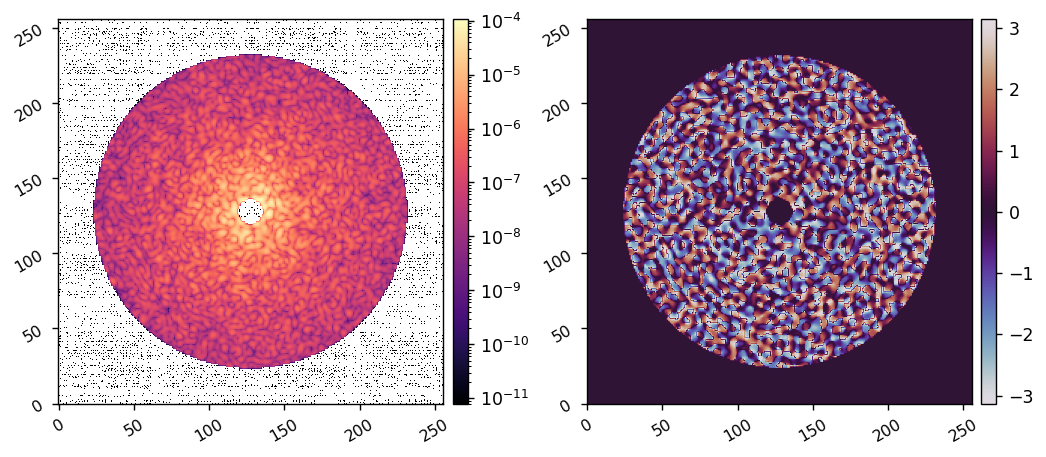

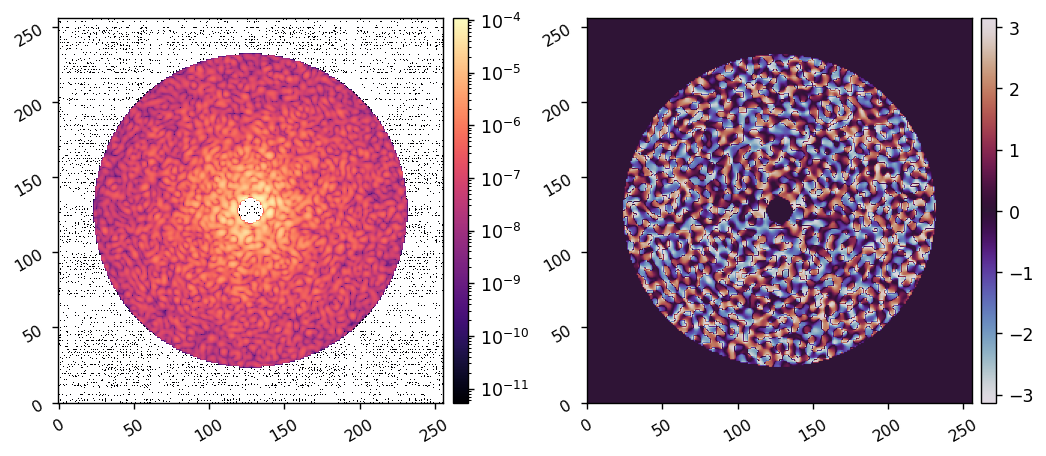

In [5]:
reload(aefc)
E_abs = aefc.calc_wfs(I, control_waves, control_mask, plot=1)


	Cost-function J_delE: 0.026
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.026
	Total cost-function value: 1.000

	Cost-function J_delE: 0.025
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.025
	Total cost-function value: 1.000

	Cost-function J_delE: 0.023
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.023
	Total cost-function value: 1.000



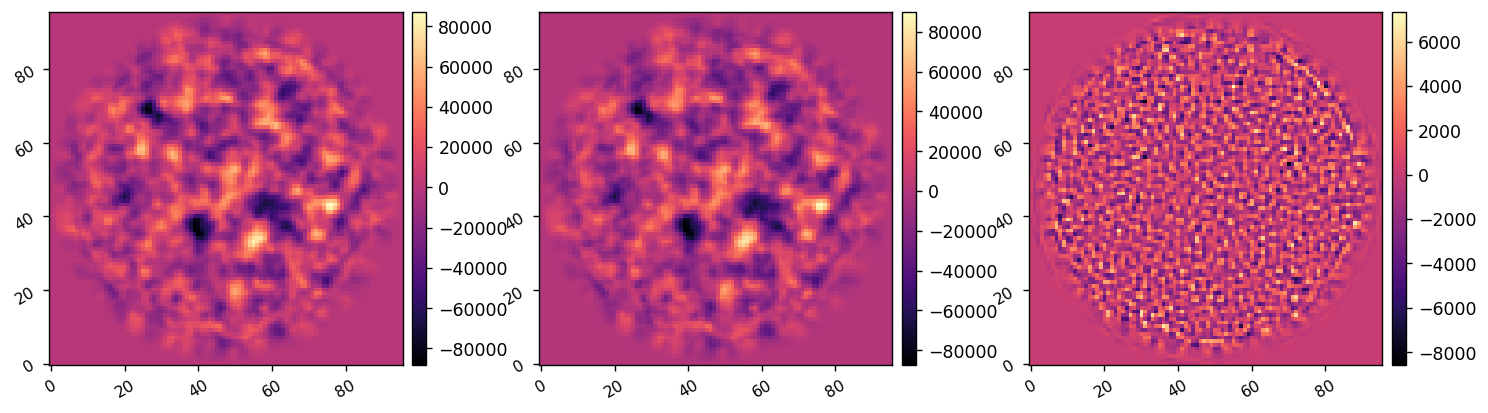

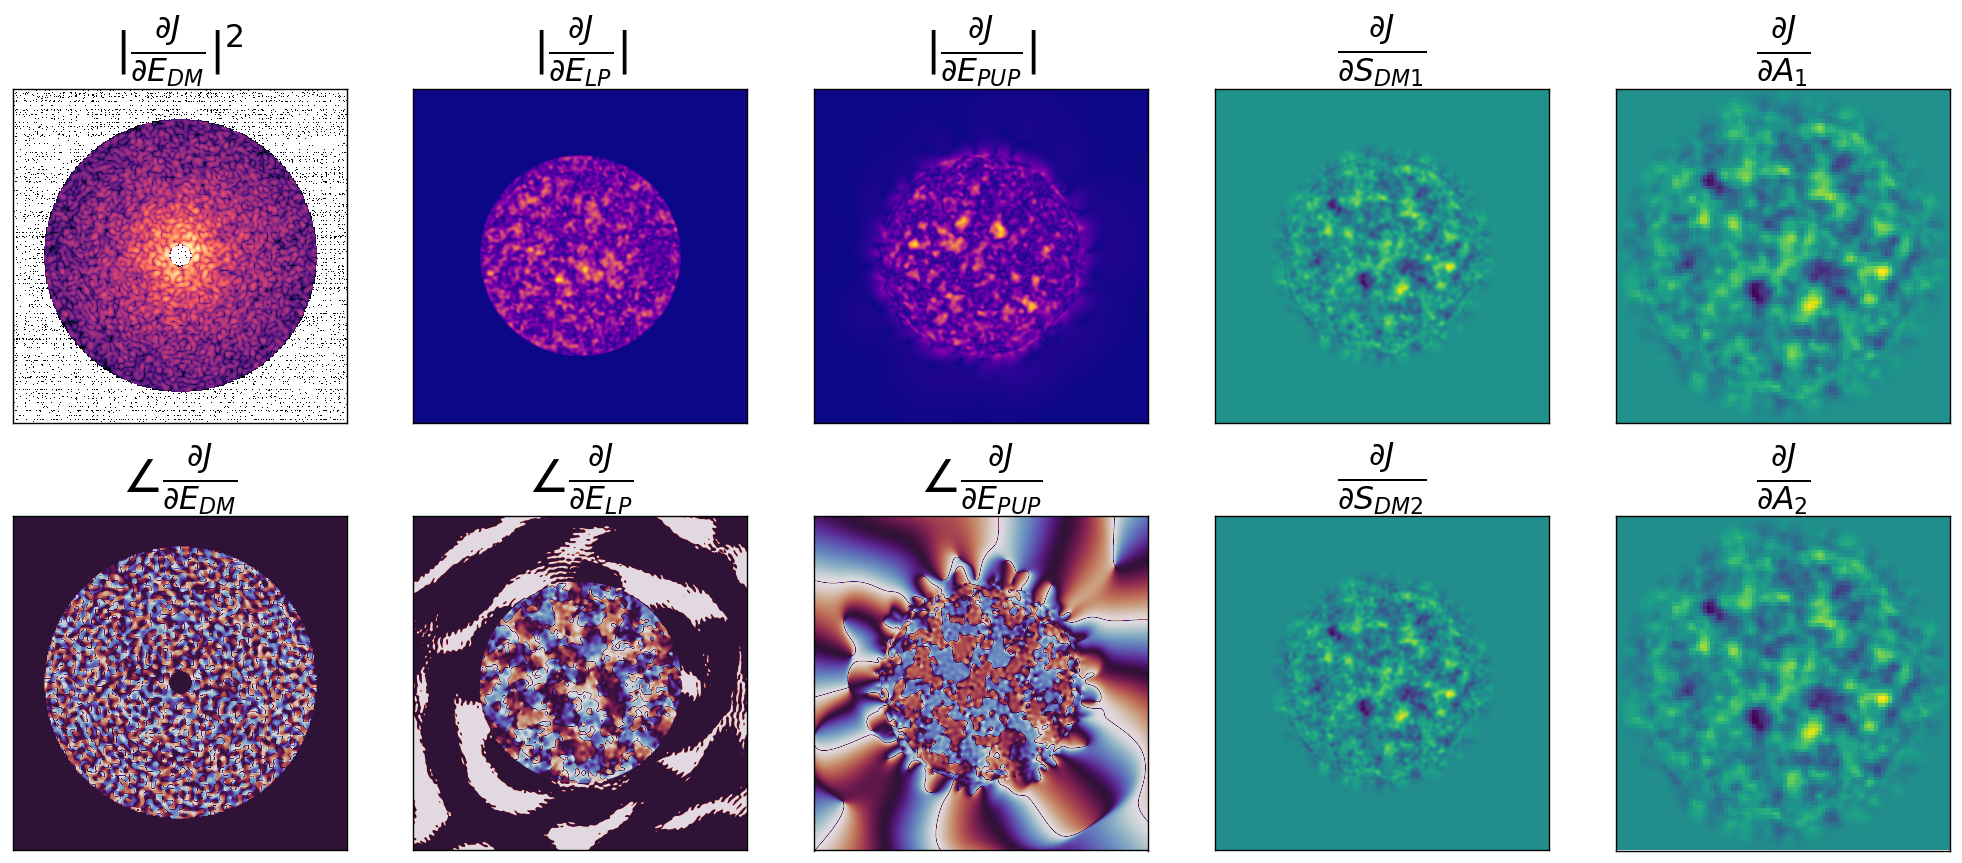

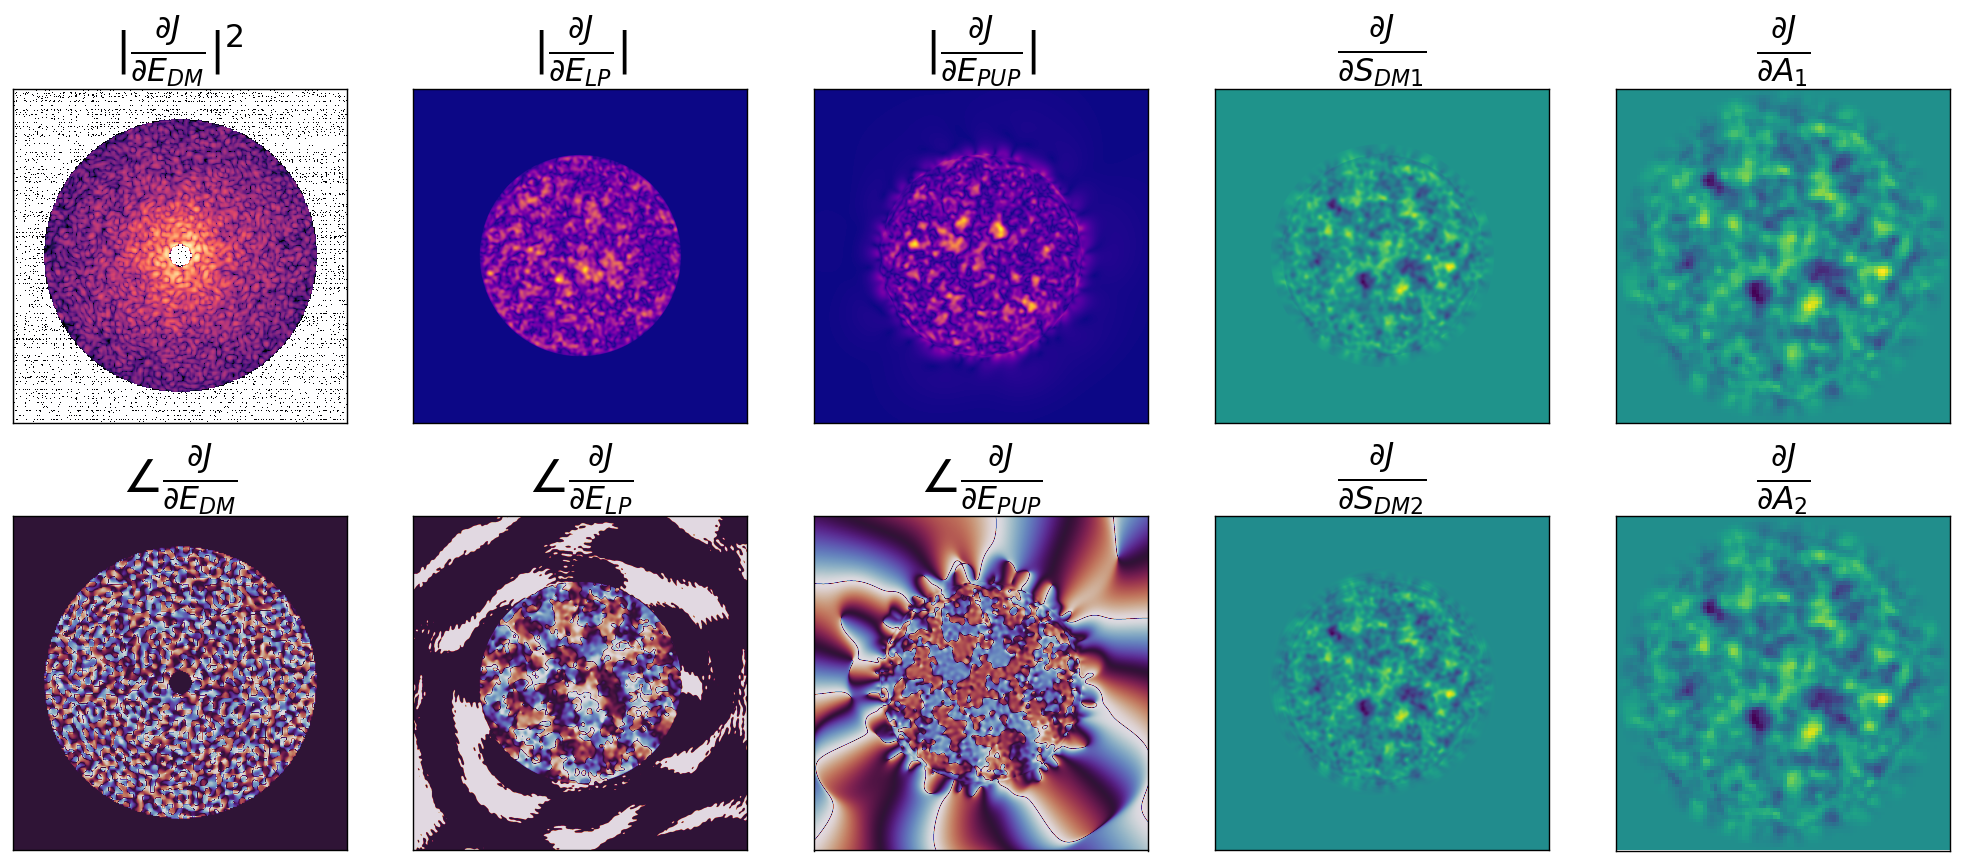

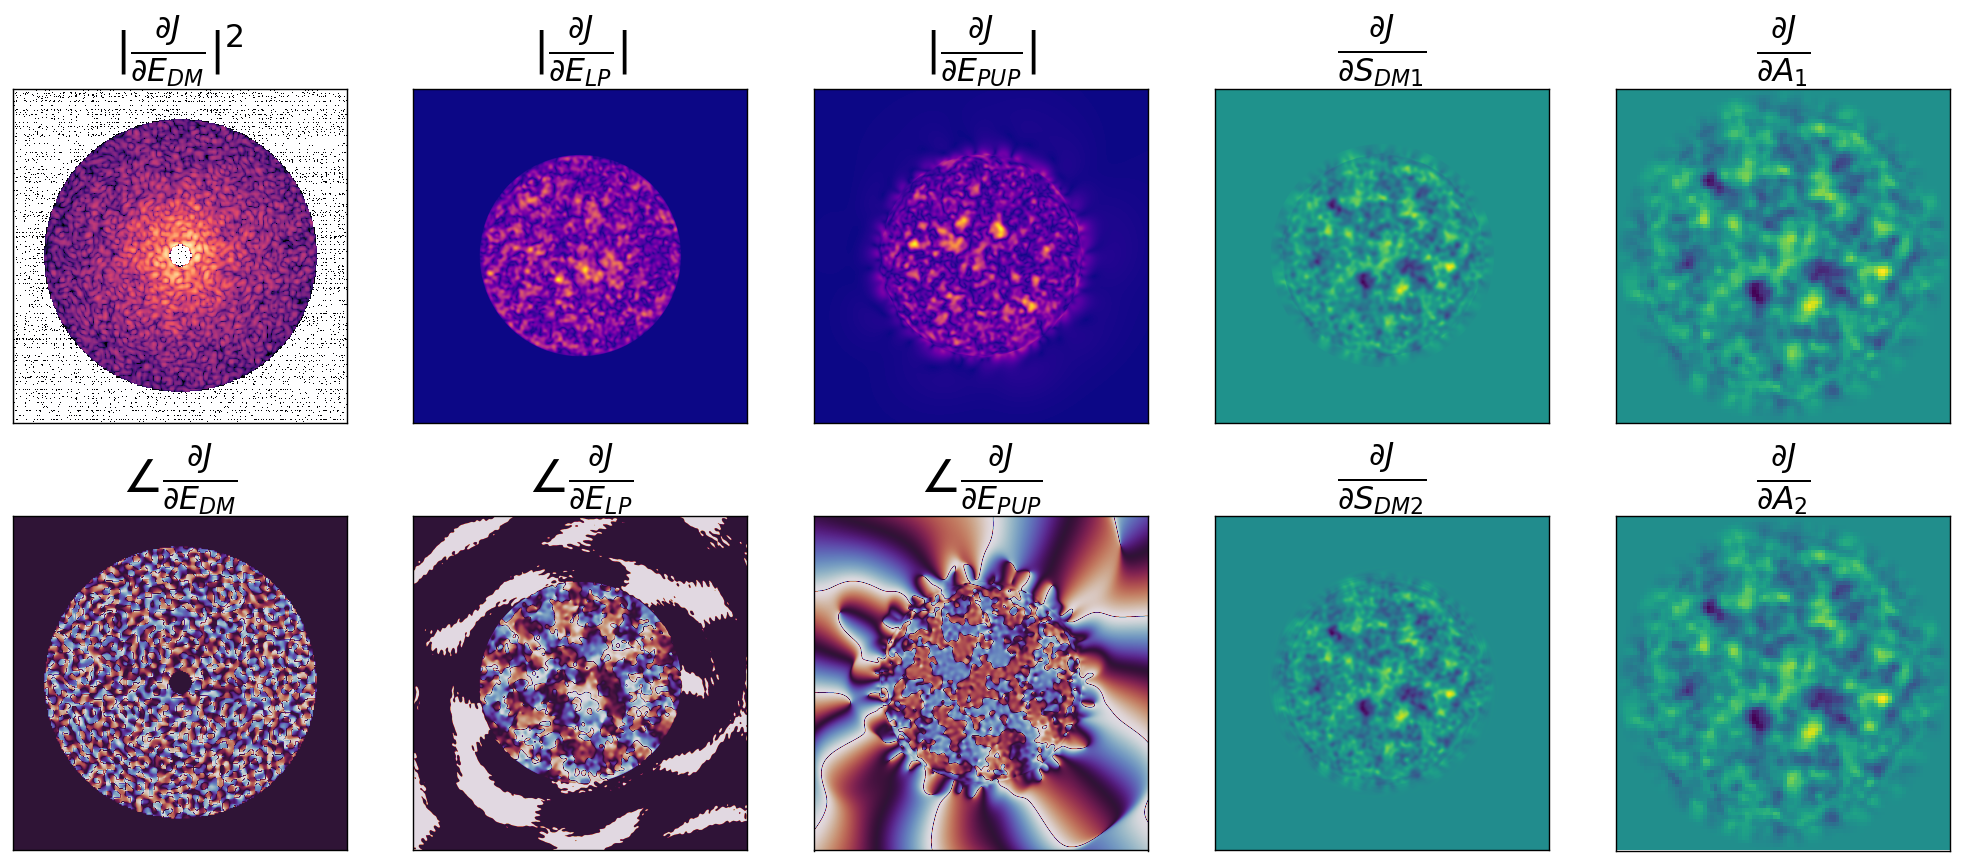

In [10]:
reload(fraunhofer)
reload(aefc)
current_acts = xp.zeros(M.Nacts)
# current_acts = fits.getdata('ad_test_acts.fits')

I.reset_dms()
I.add_dm1(fraunhofer.acts_to_command(current_acts[:M.Nacts//2], M.dm_mask))
I.add_dm2(fraunhofer.acts_to_command(current_acts[M.Nacts//2:], M.dm_mask))

E_abs = aefc.calc_wfs(I, control_waves, control_mask, plot=0)
# E_FP_NOMs, E_EPs, E_DM2Ps, DM1_PHASORs, DM2_PHASORs = aefc.get_forward_vars(M, current_acts, control_waves)
E_FP_NOMs = aefc.get_E_NOMs(M, current_acts, control_waves)

rmad_vars = { 
    'current_acts':current_acts,
    'E_abs':E_abs, 
    'E_FP_NOMs':E_FP_NOMs,
    'control_mask':control_mask,
    'control_waves':control_waves,
    'r_cond':1e-3,
    'weights':None,
    # 'weights':np.array([10,1,10]), 
}

del_acts = np.zeros(M.Nacts)
J, dJ_dA = fraunhofer.val_and_grad_bb(
    del_acts, 
    M, rmad_vars, 
    verbose=True, 
    # plot=True, 
    fancy_plot=True,
)

dm1_grad = fraunhofer.acts_to_command(dJ_dA[:M.Nacts//2], M.dm_mask)
dm2_grad = fraunhofer.acts_to_command(dJ_dA[M.Nacts//2:], M.dm_mask)
imshow3(dm1_grad, dm2_grad, dm2_grad-dm1_grad)

In [11]:
reload(fraunhofer)
reload(aefc)

current_acts = xp.zeros(M.Nacts)
# current_acts = fits.getdata('ad_test_acts.fits')

I.reset_dms()
I.add_dm1(fraunhofer.acts_to_command(current_acts[:M.Nacts//2], M.dm_mask))
I.add_dm2(fraunhofer.acts_to_command(current_acts[M.Nacts//2:], M.dm_mask))

E_abs = aefc.calc_wfs(I, control_waves, control_mask, plot=0)
E_FP_NOMs = aefc.get_E_NOMs(M, current_acts, control_waves)

rmad_vars = { 
    'current_acts':current_acts,
    'E_abs':E_abs, 
    'E_FP_NOMs':E_FP_NOMs,
    'control_mask':control_mask,
    'control_waves':control_waves,
    'r_cond':1e-3,
    'weights':None,
    # 'weights':np.array([10,1,10]), 
}

bfgs_tol = 1e-3
bfgs_opts = {
    'disp':True,
    # 'maxls':50,
    # 'ftol':1e-6,
    # 'gtol':1e-6,
}

del_acts0 = np.zeros(M.Nacts)
res = minimize(
    fraunhofer.val_and_grad_bb, 
    jac=True, 
    x0=del_acts0,
    args=(M, rmad_vars, True, False), 
    method='L-BFGS-B',
    tol=bfgs_tol,
    options=bfgs_opts,
)


	Cost-function J_delE: 0.026
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.026
	Total cost-function value: 1.000

	Cost-function J_delE: 0.025
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.025
	Total cost-function value: 1.000

	Cost-function J_delE: 0.023
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.023
	Total cost-function value: 1.000

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  8.99053D+04
	Cost-function J_delE: 0.056
	Cost-function J_c: 2366863905.325
	Cost-function normalization factor: 0.026
	Total cost-function value: 90596754489.870



 This problem is unconstrained.


	Cost-function J_delE: 0.052
	Cost-function J_c: 2366863905.325
	Cost-function normalization factor: 0.025
	Total cost-function value: 95726783741.519

	Cost-function J_delE: 0.046
	Cost-function J_c: 2366863905.325
	Cost-function normalization factor: 0.023
	Total cost-function value: 101032466451.429

	Cost-function J_delE: 8.892
	Cost-function J_c: 0.038
	Cost-function normalization factor: 0.026
	Total cost-function value: 341.805

	Cost-function J_delE: 8.791
	Cost-function J_c: 0.038
	Cost-function normalization factor: 0.025
	Total cost-function value: 357.085

	Cost-function J_delE: 8.694
	Cost-function J_c: 0.038
	Cost-function normalization factor: 0.023
	Total cost-function value: 372.734

	Cost-function J_delE: 0.018
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.026
	Total cost-function value: 0.690

	Cost-function J_delE: 0.017
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.025
	Total cost-function value: 0.692

	Cost-function J_delE: 0

7.375895756033868e-07 8.759407657380793e-09


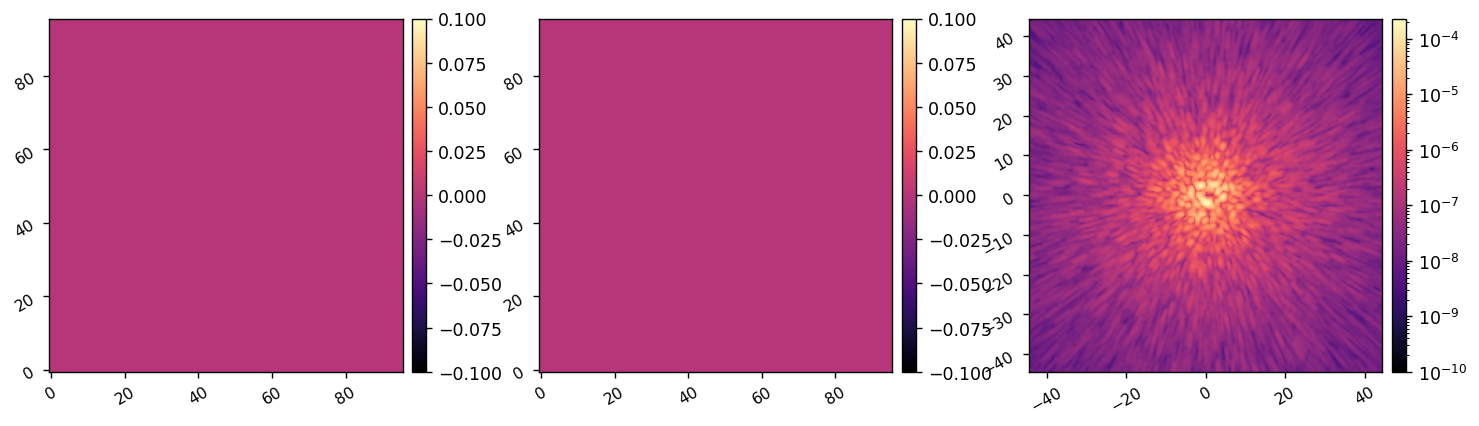

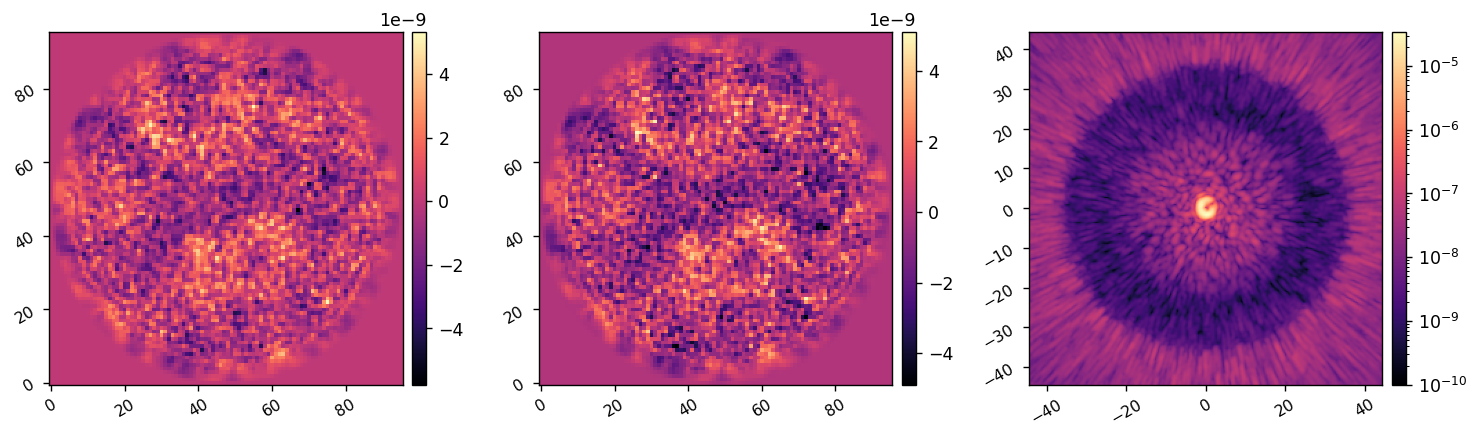

In [12]:
I.reset_dms()
old_dm1 = I.get_dm1()
old_dm2 = I.get_dm2()
old_im = I.snap()

del_dm1 = fraunhofer.acts_to_command(res.x[:M.Nacts//2], I.dm_mask)
del_dm2 = fraunhofer.acts_to_command(res.x[M.Nacts//2:], I.dm_mask)
I.add_dm1(del_dm1)
I.add_dm2(del_dm2)
new_im = I.snap()

print(xp.mean(old_im[control_mask]), xp.mean(new_im[control_mask]))
imshow3(old_dm1, old_dm2, old_im, lognorm3=True, pxscl3=I.psf_pixelscale_lamDc, vmin3=1e-10,)
imshow3(del_dm1, del_dm2, new_im, lognorm3=True, pxscl3=I.psf_pixelscale_lamDc, vmin3=1e-10,)

In [18]:
utils.save_fits('ad_test_acts.fits', res.x)

Saved data to:  ad_test_acts.fits


In [7]:
I.reset_dms()
data = {
    # 'ref_im':ref_coro_im, 
    'images':[ref_coro_im],
    'efields':[],
    'dm1_commands':[],
    'del_dm1_commands':[],
    'dm2_commands':[],
    'del_dm2_commands':[],
    'reg_conds':[],
    'bfgs_tols':[],
    'pixelscale':I.psf_pixelscale_lamDc,
    'control_mask':control_mask, 
}

In [26]:
mem_usage_while_doing_aefc = 8.658

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  1.34696D+06


 This problem is unconstrained.



At iterate    1    f=  9.98391D-01    |proj g|=  1.12826D+06

At iterate    2    f=  9.90894D-01    |proj g|=  4.62961D+05

At iterate    3    f=  9.88794D-01    |proj g|=  4.66572D+05

At iterate    4    f=  9.85226D-01    |proj g|=  5.27433D+05

At iterate    5    f=  9.85007D-01    |proj g|=  1.19897D+06

At iterate    6    f=  9.82188D-01    |proj g|=  3.65635D+05

At iterate    7    f=  9.80985D-01    |proj g|=  2.48603D+05

At iterate    8    f=  9.79135D-01    |proj g|=  4.18350D+05

At iterate    9    f=  9.77148D-01    |proj g|=  4.06035D+05

At iterate   10    f=  9.76895D-01    |proj g|=  4.01082D+05

At iterate   11    f=  9.74303D-01    |proj g|=  3.06544D+05

At iterate   12    f=  9.72329D-01    |proj g|=  2.64123D+05

At iterate   13    f=  9.72125D-01    |proj g|=  9.45131D+05

At iterate   14    f=  9.68381D-01    |proj g|=  3.61793D+05

At iterate   15    f=  9.67026D-01    |proj g|=  3.31966D+05

At iterate   16    f=  9.63958D-01    |proj g|=  5.76294D+05

At iter

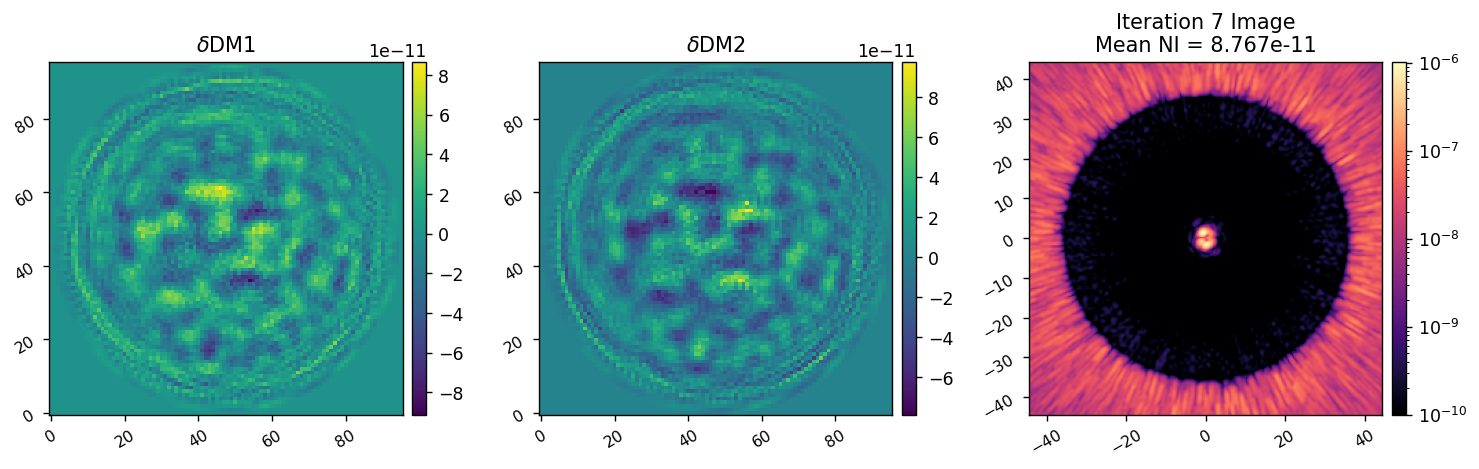

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  5.25191D+05


 This problem is unconstrained.



At iterate    1    f=  9.99658D-01    |proj g|=  4.33525D+05

At iterate    2    f=  9.97818D-01    |proj g|=  3.59374D+05

At iterate    3    f=  9.96781D-01    |proj g|=  4.06727D+05

At iterate    4    f=  9.94163D-01    |proj g|=  4.72559D+05

At iterate    5    f=  9.93958D-01    |proj g|=  4.30101D+05

At iterate    6    f=  9.91815D-01    |proj g|=  2.95247D+05

At iterate    7    f=  9.90361D-01    |proj g|=  3.48477D+05

At iterate    8    f=  9.89448D-01    |proj g|=  8.55572D+05

At iterate    9    f=  9.87250D-01    |proj g|=  2.83344D+05

At iterate   10    f=  9.86525D-01    |proj g|=  2.34006D+05

At iterate   11    f=  9.85155D-01    |proj g|=  3.82846D+05

At iterate   12    f=  9.84878D-01    |proj g|=  7.00088D+05

At iterate   13    f=  9.83802D-01    |proj g|=  2.88659D+05

At iterate   14    f=  9.83239D-01    |proj g|=  1.98182D+05

At iterate   15    f=  9.82778D-01    |proj g|=  2.69959D+05

At iterate   16    f=  9.81841D-01    |proj g|=  4.56524D+05

At iter

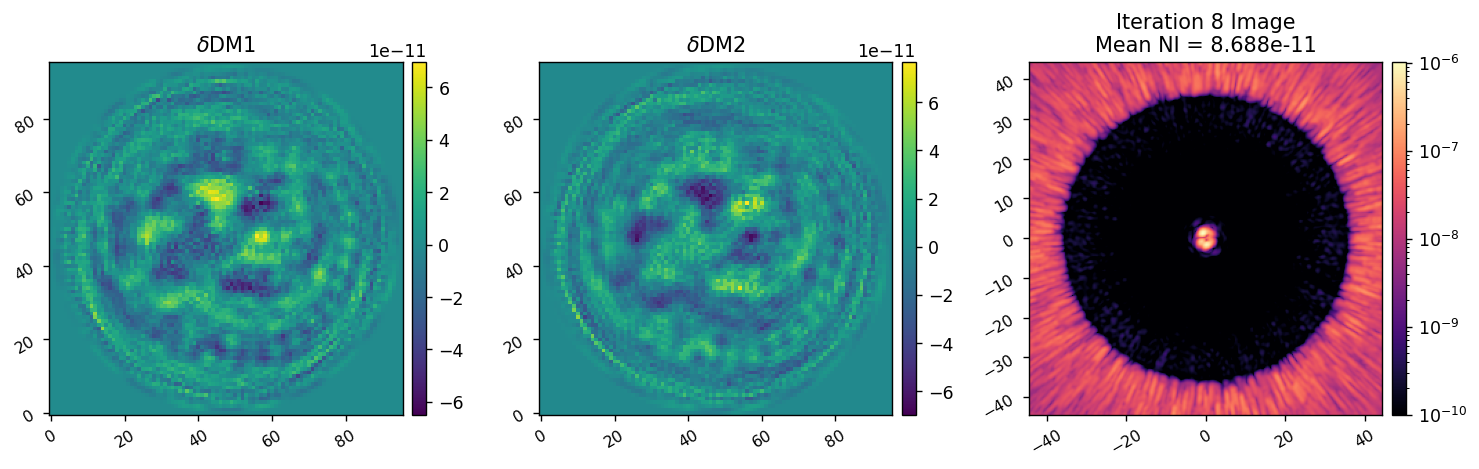

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  5.20418D+05


 This problem is unconstrained.



At iterate    1    f=  9.99663D-01    |proj g|=  4.29585D+05

At iterate    2    f=  9.97776D-01    |proj g|=  4.21423D+05

At iterate    3    f=  9.96671D-01    |proj g|=  4.16909D+05

At iterate    4    f=  9.95251D-01    |proj g|=  6.18854D+05

At iterate    5    f=  9.94210D-01    |proj g|=  4.73499D+05

At iterate    6    f=  9.93609D-01    |proj g|=  2.81013D+05

At iterate    7    f=  9.92526D-01    |proj g|=  2.47764D+05

At iterate    8    f=  9.91613D-01    |proj g|=  4.44091D+05

At iterate    9    f=  9.90615D-01    |proj g|=  3.55949D+05

At iterate   10    f=  9.89754D-01    |proj g|=  2.67970D+05

At iterate   11    f=  9.88956D-01    |proj g|=  2.69841D+05

At iterate   12    f=  9.88277D-01    |proj g|=  3.25013D+05

At iterate   13    f=  9.87324D-01    |proj g|=  3.07563D+05

At iterate   14    f=  9.87032D-01    |proj g|=  7.33504D+05

At iterate   15    f=  9.85812D-01    |proj g|=  3.15441D+05

At iterate   16    f=  9.85217D-01    |proj g|=  2.41076D+05

At iter

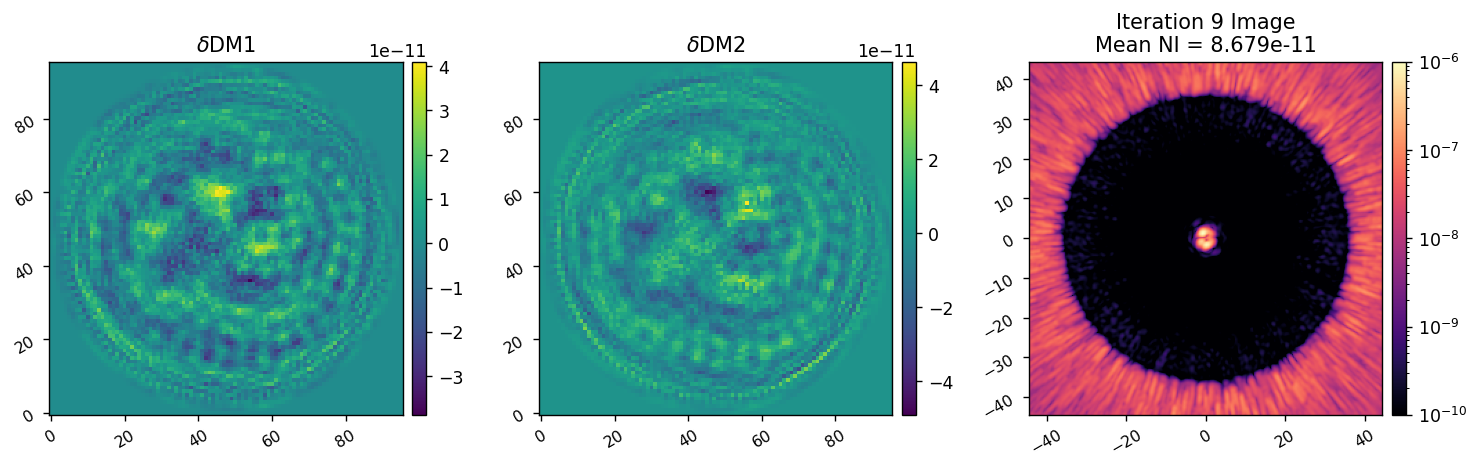

In [10]:
reload(fraunhofer)
reload(aefc)

bfgs_tol = 1e-2
bfgs_tol = 1e-3
bfgs_tol = 1e-4
# bfgs_tol = 1e-5
# bfgs_tol = 1e-10

bfgs_opts = {
    'disp':True,
    'maxls':10, 
    'maxiter':50,
    # 'ftol':1e-6,
    # 'gtol':1e-6,
}

data = aefc.run_bb(
    I, 
    M, 
    fraunhofer.val_and_grad_bb, 
    control_mask, 
    data,
    # Nitr=3, reg_cond=1e-1,
    # Nitr=3, reg_cond=1e-2,
    Nitr=3, reg_cond=1e-3,
    # Nitr=3, reg_cond=1e-4,
    # Nitr=3, reg_cond=1e-5,
    # Nitr=3, reg_cond=1e-6,
    # Nitr=3, reg_cond=1e-7,
    # Nitr=3, reg_cond=1e-8,
    # Nitr=3, reg_cond=1e-12,
    # weights=np.array([20,1,20]), 
    bfgs_tol=bfgs_tol,
    bfgs_opts=bfgs_opts,
    gain=1,
)



In [38]:
print(mem_usage_from_fresnel_model, mem_usage_with_forward_model, mem_usage_while_doing_aefc)

3.794 6.482 8.658


In [37]:
aefc_mem_usage = mem_usage_while_doing_aefc - mem_usage_from_fresnel_model
print(aefc_mem_usage)
aefc_mem_usage = mem_usage_while_doing_aefc - mem_usage_with_forward_model
print(aefc_mem_usage)

4.863999999999999
2.1759999999999993


In [24]:
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
now = datetime.now().strftime('%Y%m%d%H%M%S')
utils.save_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/fresnel_96_aefc_run_{now}.pkl', data)

Saved data to:  /npool/nvme/kianmilani/aefc-vortex-data/fresnel_96_aefc_run_20250424110931.pkl
